# Data Scrape and Plots
All 28 txt files and the Excel file must be stored in the same directory as this notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

## Gather Data
Read in data from Excel and all txt files, extract steady-state sections for each run.

In [3]:
# Use SummaryResults.csv instead of Excel, and use PE_ss_start/PE_ss_end for steady-state window
csv_file = 'SummaryResults.csv'
data = pd.read_csv(csv_file)

run_num_arr = data['Run'].to_numpy()
throttle_arr = data['Throttle %'].to_numpy()
current_arr = data['Current [A]'].to_numpy()
speed_arr = data['Tacho speed'].to_numpy()
torque_arr = data['Torque [Nm]'].to_numpy()
PE_ss_start = data['Line start ss'].to_numpy()
PE_ss_end = data['Line Finish ss'].to_numpy()
file_names = data['File']

PE_runs = []
for i in range(len(run_num_arr)):
    ss_begin = int(PE_ss_start[i]) - 1  # Python is 0-indexed
    ss_finish = int(PE_ss_end[i]) - 1
    Filename = file_names.iloc[i] if hasattr(file_names, 'iloc') else file_names[i]
    print(f'Processing Run {i+1}: {Filename} (lines {ss_begin+1} to {ss_finish+1})')
    PE_data = np.loadtxt(Filename, delimiter=',', usecols=range(6))
    ss_data = PE_data[ss_begin:ss_finish+1, :]
    run = {
        'run_number': run_num_arr[i],
        'throttle': throttle_arr[i],
        'filename': Filename,
        'ss_millis': ss_data[:, 0],
        'ss_battery_current': ss_data[:, 1],
        'ss_motor_current': ss_data[:, 2],
        'ss_battery_voltage': ss_data[:, 3],
        'ss_motor_voltage': ss_data[:, 4],
        'num_samples': ss_data.shape[0],
        'ss_battery_power': ss_data[:, 3] * ss_data[:, 1],
        'ss_motor_power': ss_data[:, 4] * ss_data[:, 2],
        'avg_battery_current': np.mean(ss_data[:, 1]),
        'avg_motor_current': np.mean(ss_data[:, 2]),
        'avg_battery_voltage': np.mean(ss_data[:, 3]),
        'avg_motor_voltage': np.mean(ss_data[:, 4])
    }
    PE_runs.append(run)
    print(f"  Averages: Motor V={run['avg_motor_voltage']:.3f}, Motor I={run['avg_motor_current']:.3f}, Battery V={run['avg_battery_voltage']:.3f}, Battery I={run['avg_battery_current']:.3f}")
print(f'\n✓ Processed {len(run_num_arr)} runs successfully!\n')

Processing Run 1: ILTESTr016.txt (lines 4705 to 4946)
  Averages: Motor V=5.860, Motor I=1.930, Battery V=28.462, Battery I=0.906
Processing Run 2: ILTESTr017.txt (lines 402 to 547)
  Averages: Motor V=5.860, Motor I=1.943, Battery V=28.460, Battery I=0.905
Processing Run 3: ILTESTr017.txt (lines 785 to 1004)
  Averages: Motor V=5.848, Motor I=2.386, Battery V=28.439, Battery I=0.993
Processing Run 4: ILTESTr017.txt (lines 1246 to 1401)
  Averages: Motor V=5.839, Motor I=2.794, Battery V=28.424, Battery I=1.078
Processing Run 5: ILTESTr017.txt (lines 2024 to 2174)
  Averages: Motor V=5.831, Motor I=3.252, Battery V=28.405, Battery I=1.168
Processing Run 6: ILTESTr017.txt (lines 2284 to 2402)
  Averages: Motor V=5.821, Motor I=3.710, Battery V=28.386, Battery I=1.254
Processing Run 7: ILTESTr017.txt (lines 2532 to 2663)
  Averages: Motor V=5.814, Motor I=4.066, Battery V=28.372, Battery I=1.327
Processing Run 8: ILTESTr018.txt (lines 195 to 287)
  Averages: Motor V=5.808, Motor I=4.330,

## Plot 1 — Voltage & Current vs Time
Prompt for a run number and plot motor/battery current and voltage over the steady-state time window.

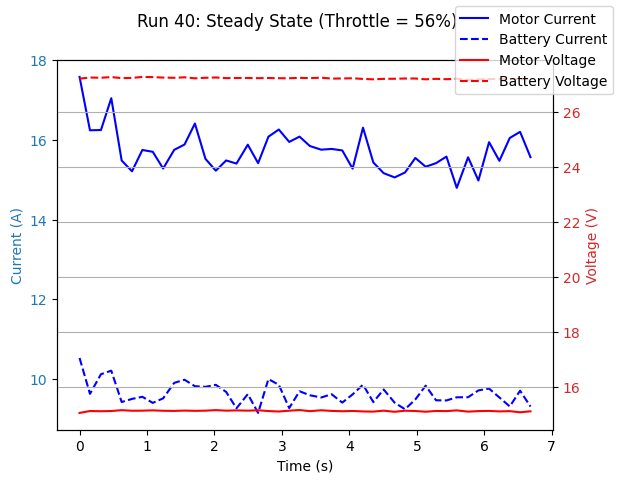

Averages:
Motor Current: 15.727 A
Battery Current: 9.635 A
Motor Voltage: 15.142 V
Battery Voltage: 27.225 V


In [5]:
run_to_plot = int(input(f'Enter run number to plot (1 to {len(run_num_arr)}): '))
if run_to_plot < 1 or run_to_plot > len(run_num_arr):
    raise ValueError(f'Invalid run number! Must be between 1 and {len(run_num_arr)}')
selected_run = PE_runs[run_to_plot-1]
time_ms = selected_run['ss_millis']
time_s = (time_ms - time_ms[0]) / 1000
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Current (A)', color=color)
l1, = ax1.plot(time_s, selected_run['ss_motor_current'], '-b', label='Motor Current')
l2, = ax1.plot(time_s, selected_run['ss_battery_current'], '--b', label='Battery Current')
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:red'
l3, = ax2.plot(time_s, selected_run['ss_motor_voltage'], '-r', label='Motor Voltage')
l4, = ax2.plot(time_s, selected_run['ss_battery_voltage'], '--r', label='Battery Voltage')
ax2.set_ylabel('Voltage (V)', color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.suptitle(f'Run {run_to_plot}: Steady State (Throttle = {selected_run["throttle"]}%)')
fig.legend([l1, l2, l3, l4], ['Motor Current', 'Battery Current', 'Motor Voltage', 'Battery Voltage'], loc='upper right')
plt.grid(True)
plt.show()
print(f"Averages:\nMotor Current: {selected_run['avg_motor_current']:.3f} A\nBattery Current: {selected_run['avg_battery_current']:.3f} A\nMotor Voltage: {selected_run['avg_motor_voltage']:.3f} V\nBattery Voltage: {selected_run['avg_battery_voltage']:.3f} V")

## Second Plot — Power vs Time
Prompt for a run number and show battery, motor and mechanical power. Calculate efficiencies.

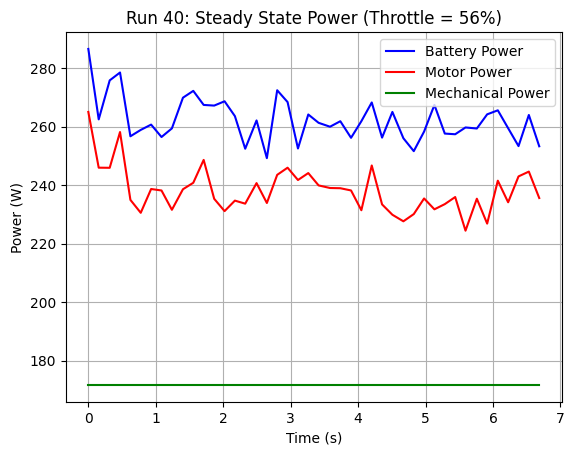

Average Powers:
Battery Power: 262.328 W
Motor Power: 238.128 W
Mechanical Power: 171.662 W
η_PE: 90.78%
η_mech: 72.09%
η_overall: 65.44%


In [6]:
run_to_plot2 = int(input(f'Enter run number to plot power data (1 to {len(run_num_arr)}): '))
if run_to_plot2 < 1 or run_to_plot2 > len(run_num_arr):
    raise ValueError(f'Invalid run number! Must be between 1 and {len(run_num_arr)}')
selected_run2 = PE_runs[run_to_plot2-1]
time_ms2 = selected_run2['ss_millis']
time_s2 = (time_ms2 - time_ms2[0]) / 1000
torque_run = torque_arr[run_to_plot2-1]
speed_rpm = speed_arr[run_to_plot2-1]
speed_rad_s = speed_rpm * (2 * np.pi / 60)
mechanical_power = torque_run * speed_rad_s
fig2, axp = plt.subplots()
lb, = axp.plot(time_s2, selected_run2['ss_battery_power'], '-b', label='Battery Power')
lm, = axp.plot(time_s2, selected_run2['ss_motor_power'], '-r', label='Motor Power')
lmech, = axp.plot(time_s2, mechanical_power * np.ones_like(time_s2), '-g', label='Mechanical Power')
axp.set_ylabel('Power (W)')
axp.set_xlabel('Time (s)')
axp.set_title(f'Run {run_to_plot2}: Steady State Power (Throttle = {selected_run2["throttle"]}%)')
axp.legend(loc='best')
plt.grid(True)
plt.show()
avg_battery_power = np.mean(selected_run2['ss_battery_power'])
avg_motor_power = np.mean(selected_run2['ss_motor_power'])
PE_efficiency = (avg_motor_power / avg_battery_power) * 100
mechanical_efficiency = (mechanical_power / avg_motor_power) * 100
overall_efficiency = (PE_efficiency / 100) * (mechanical_efficiency / 100) * 100
print(f"Average Powers:\nBattery Power: {avg_battery_power:.3f} W\nMotor Power: {avg_motor_power:.3f} W\nMechanical Power: {mechanical_power:.3f} W\nη_PE: {PE_efficiency:.2f}%\nη_mech: {mechanical_efficiency:.2f}%\nη_overall: {overall_efficiency:.2f}%")

## Third Plot — 3D Efficiency Map
Create an overall efficiency surface over road speed and torque using all runs.

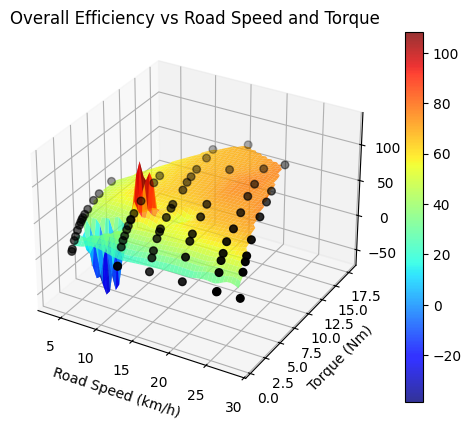

3D Efficiency surface plot created with 70 runs
Road speed range: 3.56 to 28.40 km/h


In [7]:
overall_eff_array = np.zeros(len(run_num_arr))
wheel_diameter = 0.508  # m
wheel_circumference = np.pi * wheel_diameter  # m
road_speed_kmh = (speed_arr * wheel_circumference * 60) / 1000  # km/h
for i in range(len(run_num_arr)):
    avg_batt_pwr = np.mean(PE_runs[i]['ss_battery_power'])
    avg_mot_pwr = np.mean(PE_runs[i]['ss_motor_power'])
    torque_i = torque_arr[i]
    speed_rpm_i = speed_arr[i]
    speed_rad_s_i = speed_rpm_i * (2 * np.pi / 60)
    mech_pwr_i = torque_i * speed_rad_s_i
    PE_eff_i = (avg_mot_pwr / avg_batt_pwr) * 100
    mech_eff_i = (mech_pwr_i / avg_mot_pwr) * 100
    overall_eff_array[i] = (PE_eff_i / 100) * (mech_eff_i / 100) * 100
speed_grid, torque_grid = np.meshgrid(
    np.linspace(np.min(road_speed_kmh), np.max(road_speed_kmh), 50),
    np.linspace(np.min(torque_arr), np.max(torque_arr), 50)
)
eff_grid = griddata((road_speed_kmh, torque_arr), overall_eff_array, (speed_grid, torque_grid), method='cubic')
fig3 = plt.figure()
ax3 = fig3.add_subplot(111, projection='3d')
surf = ax3.plot_surface(speed_grid, torque_grid, eff_grid, cmap='jet', edgecolor='none', alpha=0.8)
ax3.scatter(road_speed_kmh, torque_arr, overall_eff_array, c='k', s=30)
ax3.set_xlabel('Road Speed (km/h)')
ax3.set_ylabel('Torque (Nm)')
ax3.set_zlabel('η_overall (%)')
ax3.set_title('Overall Efficiency vs Road Speed and Torque')
fig3.colorbar(surf)
plt.show()
print(f'3D Efficiency surface plot created with {len(run_num_arr)} runs')
print(f'Road speed range: {np.min(road_speed_kmh):.2f} to {np.max(road_speed_kmh):.2f} km/h')

## Fourth Plot — 3D Efficiency Map (Voltage vs Current)
Plot overall efficiency over motor voltage and current, with an overlay slice at a chosen current.

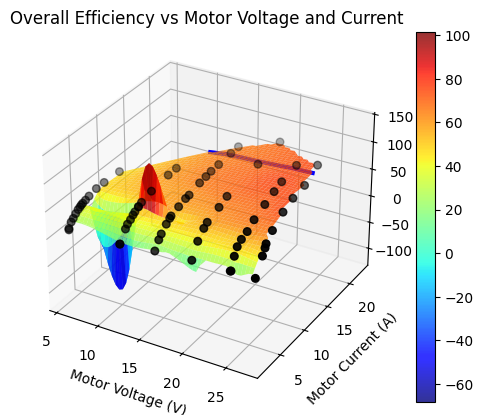

3D Efficiency plot (Voltage vs Current) created with slice at 18.0 A


In [8]:
motor_voltage_array = np.array([run['avg_motor_voltage'] for run in PE_runs])
motor_current_array = np.array([run['avg_motor_current'] for run in PE_runs])
voltage_grid, current_grid = np.meshgrid(
    np.linspace(np.min(motor_voltage_array), np.max(motor_voltage_array), 50),
    np.linspace(np.min(motor_current_array), np.max(motor_current_array), 50)
)
eff_grid_vc = griddata((motor_voltage_array, motor_current_array), overall_eff_array, (voltage_grid, current_grid), method='cubic')
fig4 = plt.figure()
ax4 = fig4.add_subplot(111, projection='3d')
surf2 = ax4.plot_surface(voltage_grid, current_grid, eff_grid_vc, cmap='jet', edgecolor='none', alpha=0.8)
slice_current = 18  # A
voltage_slice = np.linspace(np.min(motor_voltage_array), np.max(motor_voltage_array), 100)
current_slice = np.full_like(voltage_slice, slice_current)
eff_slice = griddata((motor_voltage_array, motor_current_array), overall_eff_array, (voltage_slice, current_slice), method='cubic')
ax4.plot(voltage_slice, current_slice, eff_slice, 'b-', linewidth=3)
ax4.scatter(motor_voltage_array, motor_current_array, overall_eff_array, c='k', s=30)
ax4.set_xlabel('Motor Voltage (V)')
ax4.set_ylabel('Motor Current (A)')
ax4.set_zlabel('η_overall (%)')
ax4.set_title('Overall Efficiency vs Motor Voltage and Current')
fig4.colorbar(surf2)
plt.show()
print(f'3D Efficiency plot (Voltage vs Current) created with slice at {slice_current:.1f} A')